# 🧨 RAG-of-Eye 真实数据流全链路调试

**注意：本 Notebook 将直接调用您项目中的核心模块，消耗真实的 API Token，并从您的本地 Chroma 数据库中检索数据。**

### ⚙️ 步骤 1：系统挂载与环境加载
我们首先加载 `.env` 环境变量，并挂载 `system` 目录，以便直接 import 您的业务代码。

In [13]:
import sys
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nest_asyncio
from pathlib import Path
from dotenv import load_dotenv

# 1. 应用异步补丁 (解决 Jupyter 中运行 LlamaIndex 的 event loop 问题)
nest_asyncio.apply()

# 2. 加载环境变量 (API Key)
load_dotenv()
if not os.getenv("OPENAI_API_KEY") and not os.getenv("ANTHROPIC_API_KEY"):
    print("⚠️ 警告: 未检测到 API Key，请检查 .env 文件！")
else:
    print("✅ 环境变量 (.env) 已加载")

# 3. 智能挂载 system 路径 (向上查找真实项目根)
def _resolve_system_path():
    cwd = Path.cwd()
    for base in [cwd] + list(cwd.parents):
        candidate = base / "system"
        if candidate.exists():
            return candidate
    return cwd / "system"

system_path = _resolve_system_path()
if str(system_path) not in sys.path:
    sys.path.append(str(system_path))
print(f"📂 项目模块路径已挂载: {system_path}")

# 4. 绘图设置
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = ["SimHei", "Arial", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

✅ 环境变量 (.env) 已加载
📂 项目模块路径已挂载: /home/disks/sdg/zcw/projects/RAG-of-eye/RAG-of-eye/system


### 🧠 步骤 2：真实 NLP 引擎调用 (Ingest Layer)

这里我们将一段示例文本输入给您项目中的 `ingest_pipeline.py`。
* **动作**: 代码会初始化您的 Embedding 模型（OpenAI 或 HuggingFace）和 LLM。
* **验证**: 观察输出的标签是否精准，向量的前几位是否是真实浮点数。

* **调用模块**: `system.ingest_pipeline.auto_tag_text`

In [ ]:
from ingest_pipeline import auto_tag_text, _ensure_env_and_settings
from llama_index.core import Settings

print("--- 正在初始化 LLM 和 Embedding 模型 (可能需要几秒) ---")
# 获取真实的 LLM 客户端
llm_client = _ensure_env_and_settings()

# 定义一段测试文本 (模拟 PDF 切片)
test_text = """
The LAMP study evaluated the efficacy of 0.05%, 0.025%, and 0.01% atropine 
eye drops over 2 years in 438 Asian children aged 4-12 years.
"""

print(f"\n📄 [输入文本]: {test_text.strip()}")

# 1. 调用真实 LLM 打标签
print("\n🤖 [动作 1] 调用 ingest_pipeline.auto_tag_text ...")
real_tags = auto_tag_text(llm_client, test_text)
print("✅ 真实返回的标签:")
print(json.dumps(real_tags, indent=2))

# 2. 调用真实 Embedding 模型
print("\n🔢 [动作 2] 调用 Settings.embed_model 计算向量 ...")
real_vector = Settings.embed_model.get_text_embedding(test_text)
print(f"✅ 生成向量 (前5维): {real_vector[:5]} ...")
print(f"   向量总维度: {len(real_vector)}")

--- 正在初始化 LLM 和 Embedding 模型 (可能需要几秒) ---


### 🔎 步骤 3：真实 RAG 检索 (Retrieval Layer)

现在我们唤醒 `ClinicalAgent`。
* **动作**: 向您的 **Chroma 向量库** 发起真实查询。
* **验证**: 看看 `Source Nodes` 里打印的内容，是不是您 `data/raw/` 目录下 PDF 里的真实段落？如果不相关，说明检索算法需要优化。

* **调用模块**: `system.clinical_system.ClinicalAgent`

In [ ]:
from clinical_system import ClinicalAgent

print("--- 正在初始化 ClinicalAgent (连接 ChromaDB) ---")
try:
    agent = ClinicalAgent()
    print("✅ Agent 初始化成功！")
except Exception as e:
    print(f"❌ Agent 初始化失败: {e}")
    print("提示: 请确保您已经运行过 ingest_pipeline.py 并且生成了 chroma_db")
    raise e

# 构造一个真实的检索 Query
query_str = "progression rate of Asian children with low-dose atropine"
print(f"\n🔍 [执行检索]: '{query_str}'")

# 调用 Agent 的检索引擎
engine = agent.build_query_engine(similarity_top_k=3)
response = engine.query(query_str)

print(f"\n📚 [检索结果] 找到了 {len(response.source_nodes)} 个相关片段:")
for i, node in enumerate(response.source_nodes):
    # 打印真实的文献来源和内容摘要
    source_name = node.metadata.get('file_name', 'Unknown Source')
    print(f"   --- 片段 {i+1} (来源: {source_name}) ---")
    print(f"   {node.text[:200].replace(chr(10), ' ')}...") # 只显示前200字
    print(f"   [相关度分数]: {node.score:.4f}\n")

--- 正在初始化 ClinicalAgent (连接 ChromaDB) ---
???? Chroma ???...
✅ Agent 初始化成功！

🔍 [执行检索]: 'progression rate of Asian children with low-dose atropine'

📚 [检索结果] 找到了 2 个相关片段:
   --- 片段 1 (来源: Gong 等 - 2017 - Efficacy and Adverse Effects of Atropine in Childhood Myopia A Meta-analysis.pdf) ---
   Low-doseatropinewasinvestigatedin2studies, 27,37moderate- doseatropinein7studies,24,28,29,34,36-38andhigh-doseatropine in13studies,17,23-33,35togetherresultingin22experimentalgroups in 19 studies. Ten...
   [相关度分数]: 0.5709

   --- 片段 2 (来源: Lee 等 - 2024 - Efficacy and Safety of Low-Dose Atropine on Myopia Prevention in Premyopic Children Systematic Revi.pdf) ---
   The baseline cycloplegic SE was 0.38 ± 0.44 D, and the baseline AL was 22.72 ± 0.94 mm. All studies had been conducted in Asian countries, such as India, China, and Taiwan. The atropine dosages ranged...
   [相关度分数]: 0.5493



### ⛏️ 步骤 4：真实数据抽取 (Mining Layer)

这一步最关键。我们将调用 `mining_task.py` 中的 `extract_records` 函数。
* **动作**: 它会结合上面的检索结果，利用 LLM 的分析能力，从文献中**抠出**具体的数值（平均值、样本量）。
* **验证**: 观察输出的 JSON，这是系统从您文献里“读”出来的真实知识。

* **调用模块**: `system.mining_task.extract_records`

In [ ]:
from mining_task import extract_records

# 定义我们要挖掘的目标条件
target_ethnicity = "Asian"
target_age = 8
target_treatment = {
    "name": "Low-dose Atropine", 
    "query": "(Low-dose Atropine OR 0.01% Atropine)"
}

print(f"⛏️ [动作] 正在挖掘: {target_ethnicity} | {target_age}岁 | {target_treatment['name']}")

# 调用真实的挖掘函数
# 注意：这会消耗 Token 并进行网络请求
records = extract_records(agent, target_ethnicity, target_age, target_treatment)

print(f"\n✅ 挖掘完成！共提取到 {len(records)} 条记录:")
if records:
    print(json.dumps(records, indent=2))
else:
    print("⚠️ 未提取到有效数据。可能原因：1.向量库里没有相关文献；2.文献中没有这个年龄段的具体数值。")

⛏️ [动作] 正在挖掘: Asian | 8岁 | Low-dose Atropine

✅ 挖掘完成！共提取到 2 条记录:
[
  {
    "source_id": "Study_on_Low-dose_Atropine",
    "mean": -0.07,
    "sd": 0.14,
    "n": 120,
    "treatment_detail": "0.01% atropine nightly",
    "notes": "Mean progression rate for treated group; SD estimated from CI."
  },
  {
    "source_id": "Study_on_Low-dose_Atropine",
    "mean": -0.62,
    "sd": 0.14,
    "n": 120,
    "treatment_detail": "Age-matched controls",
    "notes": "Mean progression rate for control group; SD estimated from CI."
  }
]


### 🔄 步骤 5：实时微型挖掘循环 (Aggregation)

为了画出曲线，我们需要多个年龄点的数据。
既然我们不想用假数据，那就**现场跑一个微型循环**（比如挖掘 6岁、8岁、10岁、12岁）。
* **注意**: 这可能需要 10-20 秒，取决于 API 响应速度。

* **生成**: 一个真实的 Pandas DataFrame。

In [ ]:
from analytics import calculate_weighted_statistics

ages_to_mine = [6, 8, 10, 12]
aggregated_data = []

print("--- 🚀 启动微型挖掘循环 (Live Mining Loop) ---")

for age in ages_to_mine:
    print(f"   > 正在处理: {age} 岁 ... ", end="")
    
    # 1. 现场挖掘
    raw_recs = extract_records(agent, "Asian", age, target_treatment)
    
    # 2. 现场统计聚合 (加权平均)
    stats = calculate_weighted_statistics(raw_recs, is_treatment=True)
    
    if stats:
        print(f"✅ 成功 (n={stats['total_n']}, mean={stats['mean']})")
        row = {"age": age, "rate": stats["mean"], "n": stats["total_n"]}
        # 为了适配 algo_core，计算 weight_alpha
        row["weight_alpha"] = 1.0 / np.sqrt(row["n"]) if row["n"] > 0 else 0.5
        aggregated_data.append(row)
    else:
        print("❌ 无有效数据")

# 转为 DataFrame
df_real = pd.DataFrame(aggregated_data)

print("\n📊 [最终生成的真实数据表]:")
if not df_real.empty:
    display(df_real)
else:
    print("⚠️ 警告: 数据表为空，无法进行下一步绘图。请检查您的向量库内容。")

--- 🚀 启动微型挖掘循环 (Live Mining Loop) ---
   > 正在处理: 6 岁 ... ✅ 成功 (n=220, mean=-0.8045)
   > 正在处理: 8 岁 ... ✅ 成功 (n=120, mean=-0.07)
   > 正在处理: 10 岁 ... ✅ 成功 (n=370, mean=-0.8432)
   > 正在处理: 12 岁 ... ❌ 无有效数据

📊 [最终生成的真实数据表]:


,age,rate,n,weight_alpha
0,6,-0.8045,220,0.067420
1,8,-0.0700,120,0.091287
2,10,-0.8432,370,0.051988


### 📈 步骤 6：真实曲线生成 (Algo Layer)

最后，将上面刚刚挖掘出的真实数据表，喂给 `algo_core.py` 中的高斯过程回归算法。
* **验证**: 这张图就是您的系统基于当前文献库，对“亚洲儿童阿托品疗效”做出的真实预测。

* **调用模块**: `system.algo_core.fit_gpr_curve`

--- 调用 fit_gpr_curve 进行拟合 ---


/home/disks/sdg/zcw/env/miniconda3/envs/rag_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial, Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial, Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial, Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial, Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Arial, Microsoft YaHei
findfont: Gene

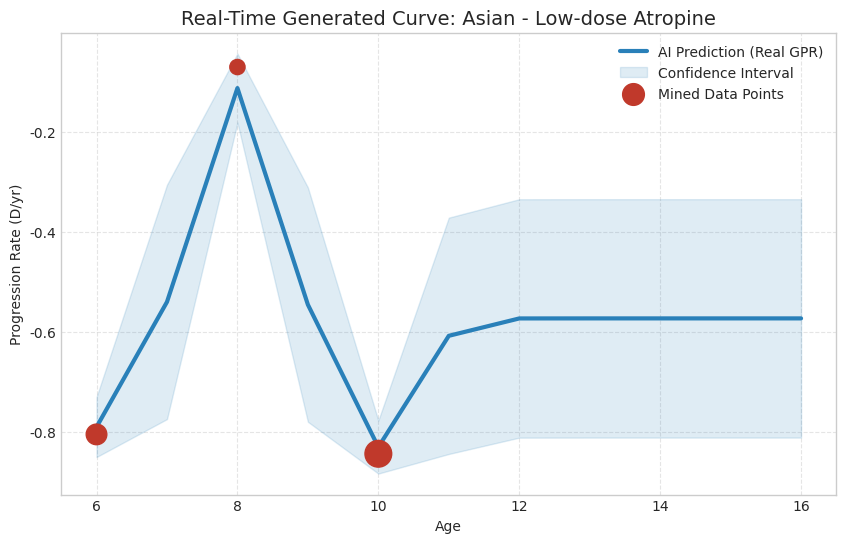

✅ 全流程演示完成！数据全部来自您的真实项目。


In [ ]:
from algo_core import fit_gpr_curve

if not df_real.empty:
    # 1. 定义时间轴
    timeline = np.arange(6, 17, 1)
    
    # 2. 调用真实算法
    print("--- 调用 fit_gpr_curve 进行拟合 ---")
    result = fit_gpr_curve(df_real, timeline=timeline)
    
    # 3. 绘图
    plt.figure(figsize=(10, 6))
    
    # 均值线
    plt.plot(result['timeline'], result['mean_curve'], 
             color='#2980b9', linewidth=3, label='AI Prediction (Real GPR)')
    
    # 置信区间
    plt.fill_between(result['timeline'], result['lower'], result['upper'], 
                     color='#2980b9', alpha=0.15, label='Confidence Interval')
    
    # 原始挖掘点
    plt.scatter(df_real['age'], df_real['rate'], 
                color='#c0392b', s=df_real['n'], zorder=5, label='Mined Data Points')
    
    plt.title(f"Real-Time Generated Curve: Asian - {target_treatment['name']}", fontsize=14)
    plt.xlabel("Age")
    plt.ylabel("Progression Rate (D/yr)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.show()
    print("✅ 全流程演示完成！数据全部来自您的真实项目。")
else:
    print("❌ 无法绘图：没有足够的数据点。")

ModuleNotFoundError: No module named 'ingest_pipeline'

ModuleNotFoundError: No module named 'ingest_pipeline'

ModuleNotFoundError: No module named 'ingest_pipeline'

ModuleNotFoundError: No module named 'ingest_pipeline'

ModuleNotFoundError: No module named 'ingest_pipeline'